# Машинное обучение, ФКН ВШЭ

## Практическое  задание 3.1 Базовая генерация признаков

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее.

In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [3]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches_train = pd.read_csv('matches_df_train.csv')
matches_test = pd.read_csv('matches_df_test.csv')

print("ТРЕНИРОВОЧНЫЕ ДАННЫЕ")
size_train = matches_train.memory_usage(deep=True).sum() / 1e6
print(f"\nShape: {matches_train.shape}")
print(f"Размер: {size_train:.2f} Мб")
print(f"\nКолонки и их типы:")
print(matches_train.dtypes)

print("\n\nТЕСТОВЫЕ ДАННЫЕ")
size_test = matches_test.memory_usage(deep=True).sum() / 1e6
print(f"\nShape: {matches_test.shape}")
print(f"Размер: {size_test:.2f} Мб")
print(f"\nКолонки и их типы:")
print(matches_test.dtypes)

print("\n\nОБЩЕЕ ОПИСАНИЕ КОЛОНОК")
print("""match_id:     уникальный идентификатор матча
date:         дата проведения матча
region:       регион сервера (категориальный признак)
game_mode:    режим игры (категориальный признак)
duration:     длительность матча (только в train)
radiant_win:  победа сил Света - целевая переменная (только в train)
avg_mmr:      средний MMR игроков матча
""")

ТРЕНИРОВОЧНЫЕ ДАННЫЕ

Shape: (641090, 7)
Размер: 97.00 Мб

Колонки и их типы:
match_id         int64
date            object
region          object
game_mode        int64
duration         int64
radiant_win       bool
avg_mmr        float64
dtype: object


ТЕСТОВЫЕ ДАННЫЕ

Shape: (59748, 5)
Размер: 8.48 Мб

Колонки и их типы:
match_id       int64
date          object
region        object
game_mode      int64
avg_mmr      float64
dtype: object


ОБЩЕЕ ОПИСАНИЕ КОЛОНОК
match_id:     уникальный идентификатор матча
date:         дата проведения матча
region:       регион сервера (категориальный признак)
game_mode:    режим игры (категориальный признак)
duration:     длительность матча (только в train)
radiant_win:  победа сил Света - целевая переменная (только в train)
avg_mmr:      средний MMR игроков матча



Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

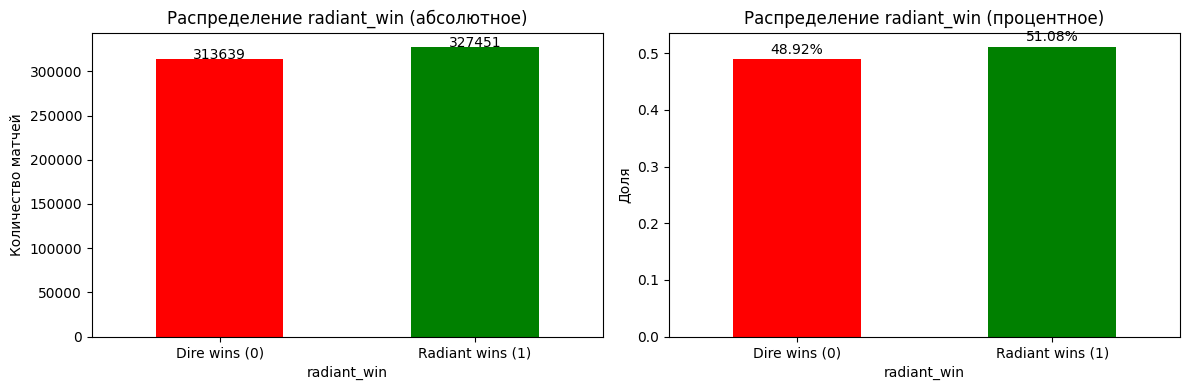

Всего матчей:  641090
Побед Radiant: 327451 (51.08%)
Побед Dire:    313639 (48.92%)


In [4]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = matches_train['radiant_win'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Распределение radiant_win (абсолютное)')
axes[0].set_xlabel('radiant_win')
axes[0].set_ylabel('Количество матчей')
axes[0].set_xticklabels(['Dire wins (0)', 'Radiant wins (1)'], rotation=0)

for i, v in enumerate(counts):
    axes[0].text(i, v + 100, str(v), ha='center')

proportions = matches_train['radiant_win'].value_counts(normalize=True).sort_index()
proportions.plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Распределение radiant_win (процентное)')
axes[1].set_xlabel('radiant_win')
axes[1].set_ylabel('Доля')
axes[1].set_xticklabels(['Dire wins (0)', 'Radiant wins (1)'], rotation=0)

for i, v in enumerate(proportions):
    axes[1].text(i, v + 0.01, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.show()

print(f"Всего матчей:  {len(matches_train)}")
print(f"Побед Radiant: {matches_train['radiant_win'].sum()} ({matches_train['radiant_win'].mean():.2%})")
print(f"Побед Dire:    {len(matches_train) - matches_train['radiant_win'].sum()} ({1 - matches_train['radiant_win'].mean():.2%})")

Тут использовал нейронку для того, чтобы по центру над барами была информация о количестве (на первой диаграмме) и о точных процентах (на второй)
Она предложила этот код -

for i, v in enumerate(proportions):
  
  axes[1].text(i, v + 0.01, f'{v:.2%}', ha='center')

в целом тут все понятно, берем по номеру столбца и значению размещаем текст в точке (i, v), добавляем сам текст и выравнивание по центру

использовал нейронку т к не знал (или забыл) как это делать

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** Да, Gini в данном случае подходящая метрика. По графику видно, что классы сбалансированы, радиант побеждает примерно в 51% матчей, а dire в 49%. ROC-AUC, а значит и джини, хорошо работает при таком балансе. AUC-PR используется когда есть сильный дисбаланс, когда важно качественно находить редкий класс (например из 1000 транзакций найти одну мощенническую)
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

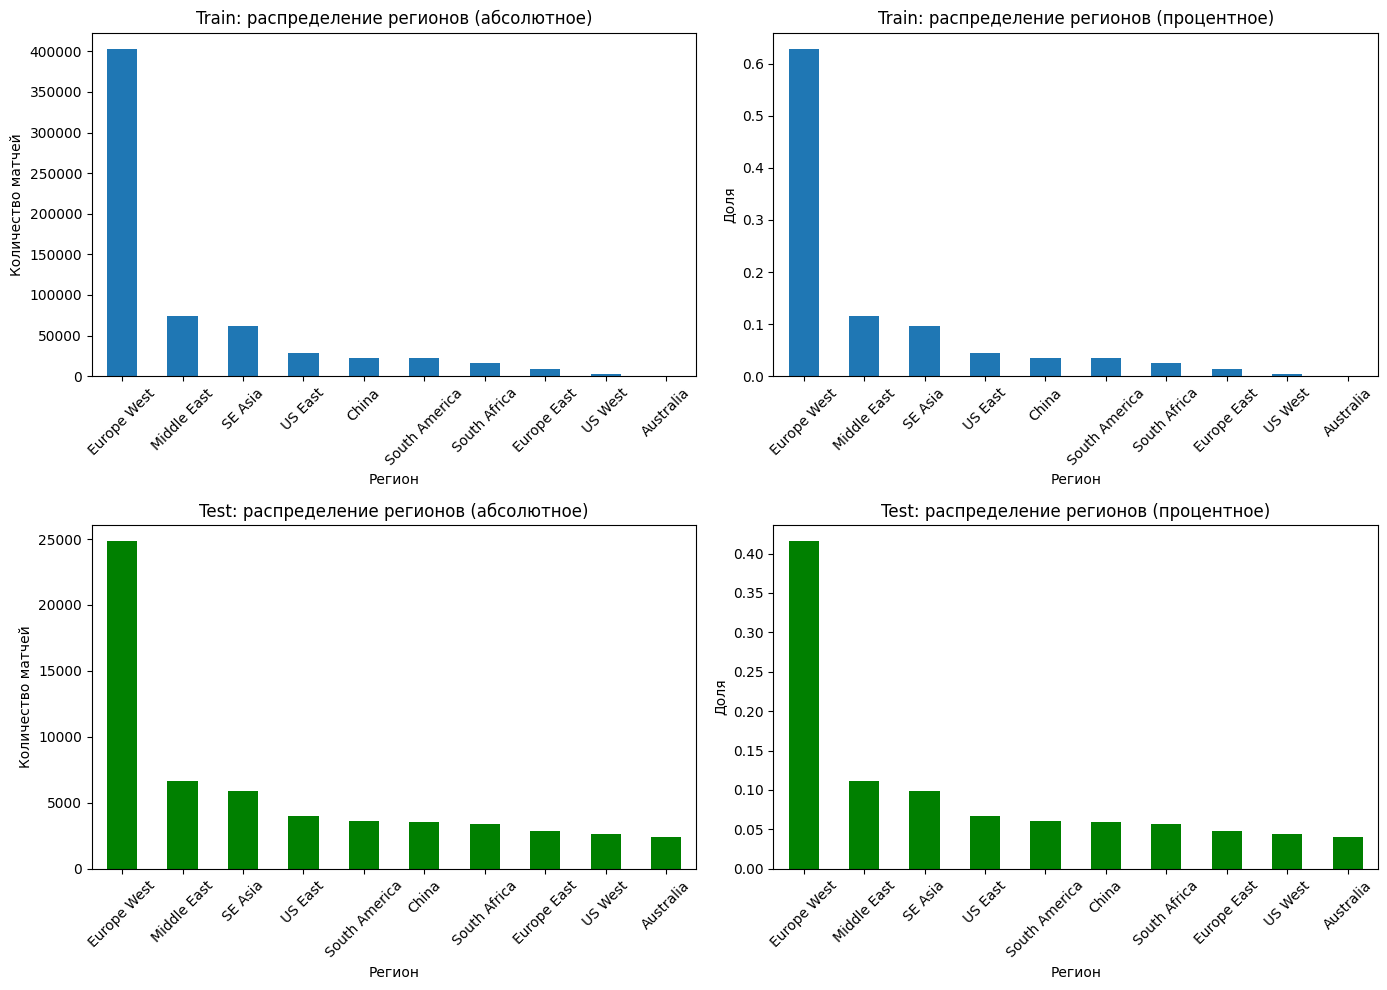

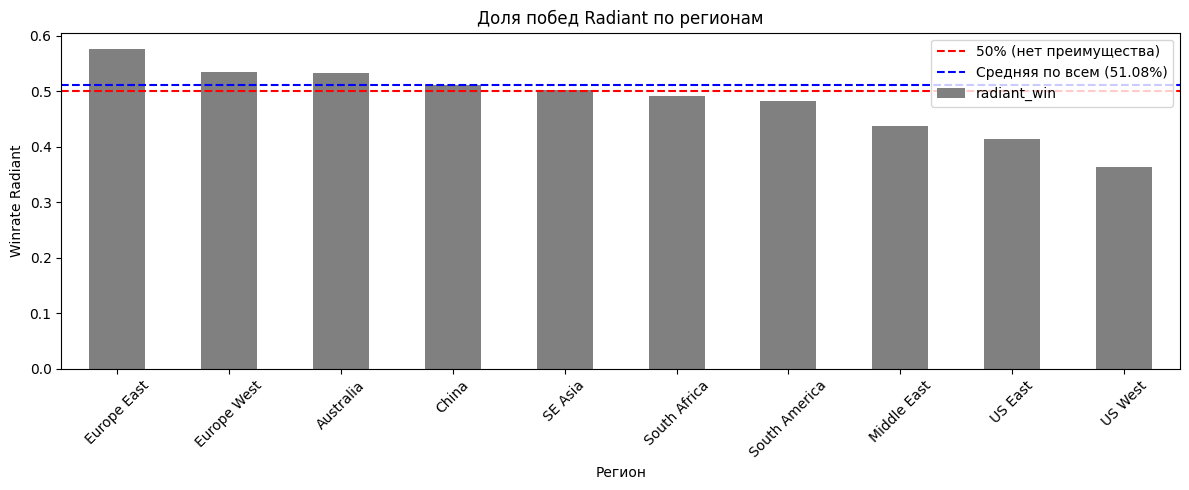

In [5]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train_counts = matches_train['region'].value_counts()
train_counts.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Train: распределение регионов (абсолютное)')
axes[0, 0].set_xlabel('Регион')
axes[0, 0].set_ylabel('Количество матчей')
axes[0, 0].tick_params(axis='x', rotation=45)

train_props = matches_train['region'].value_counts(normalize=True)
train_props.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Train: распределение регионов (процентное)')
axes[0, 1].set_xlabel('Регион')
axes[0, 1].set_ylabel('Доля')
axes[0, 1].tick_params(axis='x', rotation=45)

test_counts = matches_test['region'].value_counts()
test_counts.plot(kind='bar', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Test: распределение регионов (абсолютное)')
axes[1, 0].set_xlabel('Регион')
axes[1, 0].set_ylabel('Количество матчей')
axes[1, 0].tick_params(axis='x', rotation=45)

test_props = matches_test['region'].value_counts(normalize=True)
test_props.plot(kind='bar', ax=axes[1, 1], color='green')
axes[1, 1].set_title('Test: распределение регионов (процентное)')
axes[1, 1].set_xlabel('Регион')
axes[1, 1].set_ylabel('Доля')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


winrate_by_region = matches_train.groupby('region')['radiant_win'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
winrate_by_region.plot(kind='bar', color='gray')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% (нет преимущества)')
plt.axhline(y=matches_train['radiant_win'].mean(), color='blue', linestyle='--', label=f'Средняя по всем ({matches_train["radiant_win"].mean():.2%})')
plt.title('Доля побед Radiant по регионам')
plt.xlabel('Регион')
plt.ylabel('Winrate Radiant')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:** распределение регионов похожи на train и test, отличаются разве что положением китая и южной америки - на тесте больше матчей из южной америки, а на трейне из китая, но их разница очень мала, что на тесте, что на трейне на этих регионах +- одинаковое количество матчей, в остальном распределение по количеству матчей такое же, лидер - западная европа, а меньше всего матчей играется в австралии. Сигнал есть, в некоторых регионах игроки лучше анализируют преимущества радиант, разброс между минимальным и максимальным процентом побед на регионах +- 20%, в восточной европе ~58% против ~38% на US west. Модель обучить получится, но сигнал не очень сильный, только регион не даст высокого gini, но вместе с другими признаками все четко будет
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора

</div>

In [6]:
!pip install -qU category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.0 MB/s eta 0:00:00


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** Мне кажется наиболее привлекательным Target Encoder для этой задачи поскольку он создаст всего 1 признак вместо множества (one hot создаст столько колонок, сколько регионов), так же он кодирует связь с таргетом - региону присваивается средний винрейт, а для нашей (линейной) модели это будет более информативно
</div>

Закодируйте колонку `region` выбранным вами способом

In [7]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import category_encoders as ce

target_encoder = ce.TargetEncoder(cols=['region'])
target_encoder.fit(matches_train['region'], matches_train['radiant_win'])
matches_train['region_encoded'] = target_encoder.transform(matches_train['region'])
matches_test['region_encoded'] = target_encoder.transform(matches_test['region'])

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

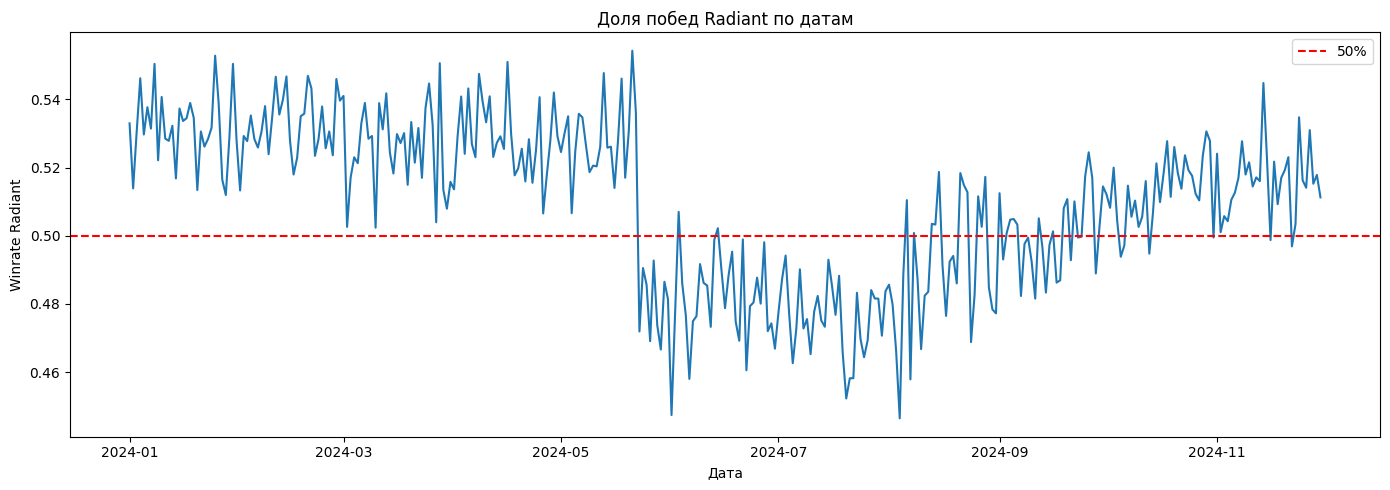

Временные диапазоны:
Train: 2024-01-01 — 2024-11-30
Test:  2024-12-01 — 2024-12-31


In [8]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])
winrate_by_date = matches_train.groupby(matches_train['date'].dt.date)['radiant_win'].mean()

plt.figure(figsize=(14, 5))
plt.plot(winrate_by_date.index, winrate_by_date.values)
plt.axhline(y=0.5, color='red', linestyle='--', label='50%')
plt.title('Доля побед Radiant по датам')
plt.xlabel('Дата')
plt.ylabel('Winrate Radiant')
plt.legend()
plt.tight_layout()
plt.show()

print("Временные диапазоны:")
print(f"Train: {matches_train['date'].min().date()} — {matches_train['date'].max().date()}")
print(f"Test:  {matches_test['date'].min().date()} — {matches_test['date'].max().date()}")

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** На графике видны резкие скачки winrate в определенные даты. Но самое резкое колебание было в июне 2024 года. Резкое падение винрейта с +- 0.54 до 0.47. При помощи сети Интеренет я нашел информацию о патче в эти даты - В начале июня 2024 года в Dota 2 вышел патч 7.36b (6 июня), который сбалансировал игру после крупного обновления 7.36. Патч затронул более 90 героев и 20 артефактов, ослабив популярных персонажей, таких как Axe, Pudge, Magnus, Sand King и Zeus, а также изменил экономику и нейтральные предметы

источник - https://dota2.net/news/111086-obnovlenie-dota-2-ot-06062024-patch-736b

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** День - можно оставить в виде числа, порядок имеет смысл. День недели - категориальный признак, тут порядок не важен (из предположений, что в пятницу вечером и в выходные актив в игре выше и это как-то влияет на распределение). Месяц - тоже категориальный, лучше закодировать (есть предположение, что летом и в январе актив выше, ибо шкильники и скуфы (на январских) наигрывают часы, тоже мб есть влияние на распределение). Час - оставим как число, мб ночью и днем в рабочие часы задротов больше и они как-то влияют на стату

Закодируем через Target Encoder

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [9]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
matches_train['day'] = matches_train['date'].dt.day
matches_train['dayofweek'] = matches_train['date'].dt.dayofweek

matches_test['day'] = matches_test['date'].dt.day
matches_test['dayofweek'] = matches_test['date'].dt.dayofweek

matches_train['month'] = matches_train['date'].dt.month
matches_train['hour'] = matches_train['date'].dt.hour

matches_test['month'] = matches_test['date'].dt.month
matches_test['hour'] = matches_test['date'].dt.hour

dayofweek_encoder = ce.TargetEncoder(cols=['dayofweek'])
dayofweek_encoder.fit(matches_train[['dayofweek']], matches_train['radiant_win'])
matches_train['dayofweek_encoded'] = dayofweek_encoder.transform(matches_train[['dayofweek']])
matches_test['dayofweek_encoded'] = dayofweek_encoder.transform(matches_test[['dayofweek']])

month_encoder = ce.TargetEncoder(cols=['month'])
month_encoder.fit(matches_train[['month']], matches_train['radiant_win'])
matches_train['month_encoded'] = month_encoder.transform(matches_train[['month']])
matches_test['month_encoded'] = month_encoder.transform(matches_test[['month']])

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Потому что данные имеют временнУю структуру. При случайном разбиении в трейн могут попасть матчи из будущего, а в валидацию из прошлого

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

И тут я осознал проблему, до этого я кодировал дату на всем трейне, теперь надо сделать валидацию, но при текущей вариации часть данных попадет в валидацию и будет утечка, поэтому для чистоты ниже я это исправлю (менять выше уже не буду, все работало, проще тут поправить, чтобы не сломать)

In [10]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
matches_train = pd.read_csv('matches_df_train.csv')
matches_test = pd.read_csv('matches_df_test.csv')
matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])

matches_train['day'] = matches_train['date'].dt.day
matches_train['dayofweek'] = matches_train['date'].dt.dayofweek
matches_train['month'] = matches_train['date'].dt.month
matches_train['hour'] = matches_train['date'].dt.hour

matches_test['day'] = matches_test['date'].dt.day
matches_test['dayofweek'] = matches_test['date'].dt.dayofweek
matches_test['month'] = matches_test['date'].dt.month
matches_test['hour'] = matches_test['date'].dt.hour

matches_train_sorted = matches_train.sort_values('date').reset_index(drop=True)
split_idx = int(len(matches_train_sorted) * 0.8)
split_date = matches_train_sorted.loc[split_idx, 'date']
train_df = matches_train_sorted[matches_train_sorted['date'] < split_date].copy()
valid_df = matches_train_sorted[matches_train_sorted['date'] >= split_date].copy()

region_encoder = ce.TargetEncoder(cols=['region'])
region_encoder.fit(train_df['region'], train_df['radiant_win'])
train_df['region_encoded'] = region_encoder.transform(train_df['region'])
valid_df['region_encoded'] = region_encoder.transform(valid_df['region'])
matches_test['region_encoded'] = region_encoder.transform(matches_test['region'])

dayofweek_encoder = ce.TargetEncoder(cols=['dayofweek'])
dayofweek_encoder.fit(train_df[['dayofweek']], train_df['radiant_win'])
train_df['dayofweek_encoded'] = dayofweek_encoder.transform(train_df[['dayofweek']])
valid_df['dayofweek_encoded'] = dayofweek_encoder.transform(valid_df[['dayofweek']])
matches_test['dayofweek_encoded'] = dayofweek_encoder.transform(matches_test[['dayofweek']])

month_encoder = ce.TargetEncoder(cols=['month'])
month_encoder.fit(train_df[['month']], train_df['radiant_win'])
train_df['month_encoded'] = month_encoder.transform(train_df[['month']])
valid_df['month_encoded'] = month_encoder.transform(valid_df[['month']])
matches_test['month_encoded'] = month_encoder.transform(matches_test[['month']])


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>:

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [11]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from sklearn.linear_model import LogisticRegression
date_features = ['day', 'hour', 'dayofweek_encoded', 'month_encoded']
region_features = ['region_encoded']
all_features = date_features + region_features
y_train = train_df['radiant_win'].astype(int)
y_valid = valid_df['radiant_win'].astype(int)

model_dates = LogisticRegression(max_iter=1000)
model_dates.fit(train_df[date_features], y_train)
pred_dates = model_dates.predict_proba(valid_df[date_features])[:, 1]
gini_dates = gini(y_valid, pred_dates)
print(f"Gini (только даты):    {gini_dates:.4f}")

model_region = LogisticRegression(max_iter=1000)
model_region.fit(train_df[region_features], y_train)
pred_region = model_region.predict_proba(valid_df[region_features])[:, 1]
gini_region = gini(y_valid, pred_region)
print(f"Gini (только регионы): {gini_region:.4f}")

model_all = LogisticRegression(max_iter=1000)
model_all.fit(train_df[all_features], y_train)
pred_all = model_all.predict_proba(valid_df[all_features])[:, 1]
gini_all = gini(y_valid, pred_all)
print(f"Gini (даты + регионы): {gini_all:.4f}")


Gini (только даты):    -0.0058
Gini (только регионы): 0.0740
Gini (даты + регионы): 0.0713


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Даты не помогли, Gini отрицательный, что означает предсказание даже хуже случайного. При добавлении дат к регионам качество упало. В целом, скорее всего даты и не должны были помогать, результаты матча не зависят от времени, в которое они сыграны, как оказалось (я не шарю в игре, не знаю ее онлайна, мое предположение о сильной разнице в онлайне, которая повлияла бы на что-то оказалось ложным). Думаю уберу даты, поскольку они делают только хуже

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

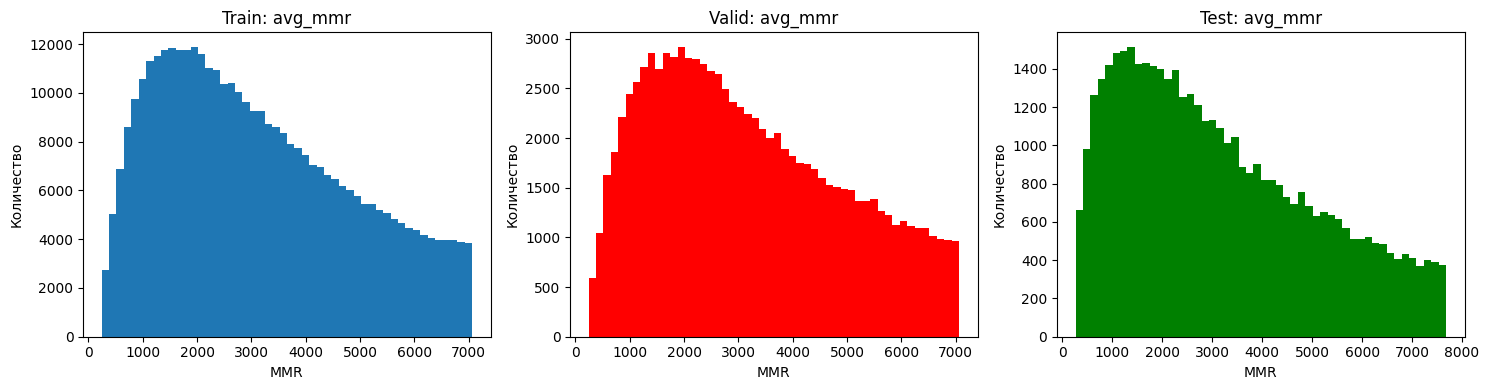

In [12]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_df['avg_mmr'].dropna(), bins=50)
axes[0].set_title(f'Train: avg_mmr')
axes[0].set_xlabel('MMR')
axes[0].set_ylabel('Количество')

axes[1].hist(valid_df['avg_mmr'].dropna(), bins=50, color='red')
axes[1].set_title(f'Valid: avg_mmr')
axes[1].set_xlabel('MMR')
axes[1].set_ylabel('Количество')

axes[2].hist(matches_test['avg_mmr'].dropna(), bins=50, color='green')
axes[2].set_title(f'Test: avg_mmr')
axes[2].set_xlabel('MMR')
axes[2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам?

**Ответ:** Распределение похоже на логнормальное или скошенное нормальное - есть один пик, но распределение асимметрично с длинным правым хвостом. Мне кажется это обычная история для рейтинговых систем, большинство игроков имеют средний рейтинг (~1300-2100), меньше игроков с очень высоким MMR (>3000) и совсем мало низких mmr. Визуально распределения очень похожи между собой

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте

Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

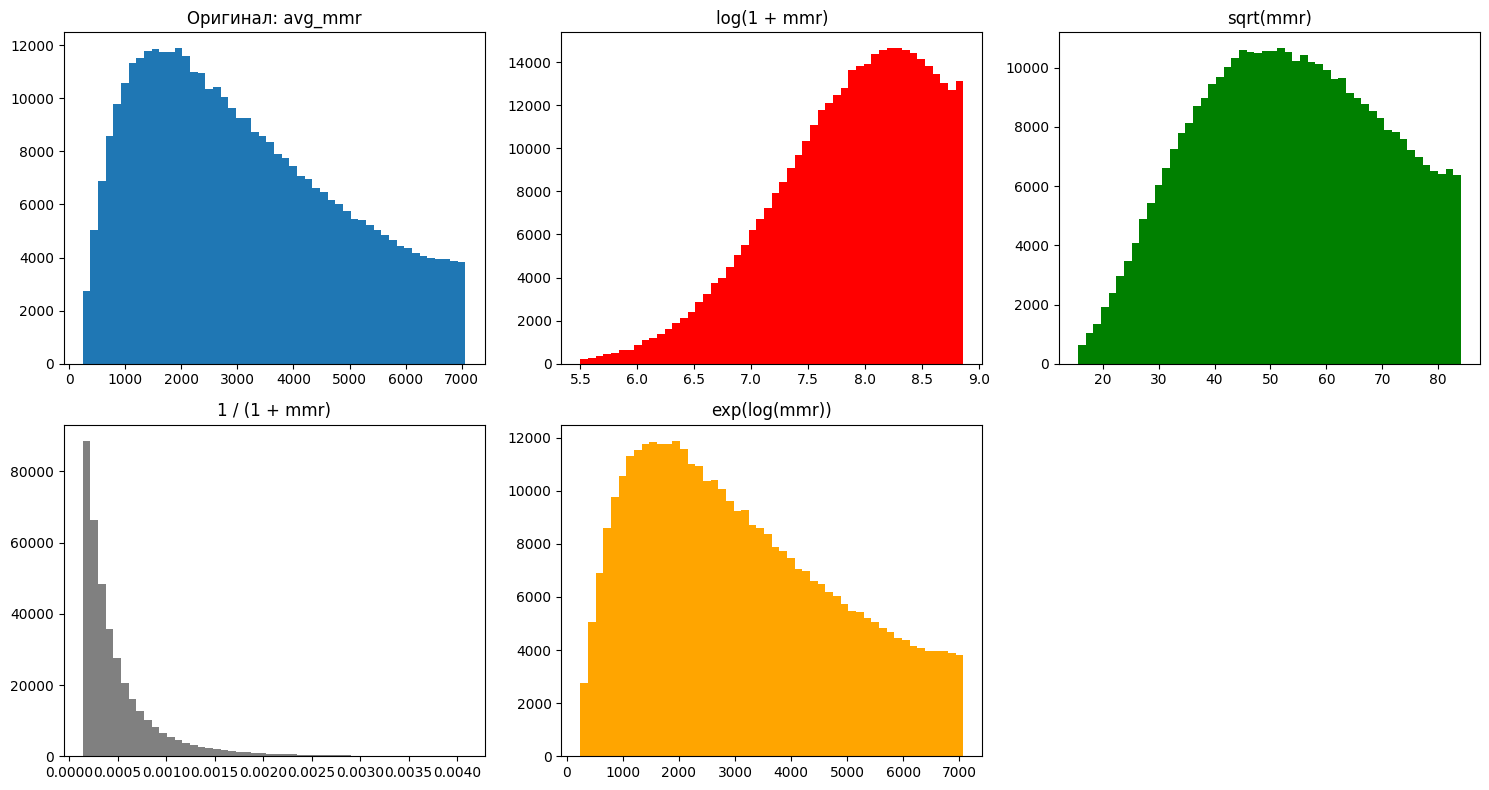

In [13]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
mmr_sample = train_df['avg_mmr'].dropna()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(mmr_sample, bins=50)
axes[0, 0].set_title('Оригинал: avg_mmr')

axes[0, 1].hist(np.log(1 + mmr_sample), bins=50, color='red')
axes[0, 1].set_title('log(1 + mmr)')

axes[0, 2].hist(np.sqrt(mmr_sample), bins=50, color='green')
axes[0, 2].set_title('sqrt(mmr)')

axes[1, 0].hist(1 / (1 + mmr_sample), bins=50, color='gray')
axes[1, 0].set_title('1 / (1 + mmr)')

axes[1, 1].hist(np.exp(np.log(mmr_sample)), bins=50, color='orange')
axes[1, 1].set_title('exp(log(mmr))')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Нет, заполнять нулем не стоит, т к ноль в нашем случае очень низкий mmr, его вообще нельзя достичь судя по тому, что пишут в интернетах, минимальный ммр 1, но ммр на старте после калибровки дают в районе 1000 и больше (опять же судя по инфе из интернетов), поэтому так все слить будет тяжело

источник - https://www.offstage.ru/dota2/articles/vse-pro-zvaniya-rejting-v-dota-2

Лучше заполнить медианой - это типичное значение MMR, которое не искажает распределение. Дополнительно создаем флаг mmr_missing, чтобы модель знала, где был пропуск - сам факт нерейтинговой игры может нести полезную информацию

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [14]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
mmr_median = train_df['avg_mmr'].median()
train_df['mmr_missing'] = train_df['avg_mmr'].isna().astype(int)
valid_df['mmr_missing'] = valid_df['avg_mmr'].isna().astype(int)
matches_test['mmr_missing'] = matches_test['avg_mmr'].isna().astype(int)

train_df['avg_mmr_filled'] = train_df['avg_mmr'].fillna(mmr_median)
valid_df['avg_mmr_filled'] = valid_df['avg_mmr'].fillna(mmr_median)
matches_test['avg_mmr_filled'] = matches_test['avg_mmr'].fillna(mmr_median)

train_df['mmr_sqrt'] = np.sqrt(train_df['avg_mmr_filled'])
valid_df['mmr_sqrt'] = np.sqrt(valid_df['avg_mmr_filled'])
matches_test['mmr_sqrt'] = np.sqrt(matches_test['avg_mmr_filled'])

region_features = ['region_encoded']
mmr_features_raw = ['region_encoded', 'avg_mmr_filled', 'mmr_missing']
mmr_features_sqrt = ['region_encoded', 'mmr_sqrt', 'mmr_missing']

model_region = LogisticRegression(max_iter=1000)
model_region.fit(train_df[region_features], y_train)
pred_region = model_region.predict_proba(valid_df[region_features])[:, 1]
gini_region = gini(y_valid, pred_region)

model_mmr_raw = LogisticRegression(max_iter=1000)
model_mmr_raw.fit(train_df[mmr_features_raw], y_train)
pred_mmr_raw = model_mmr_raw.predict_proba(valid_df[mmr_features_raw])[:, 1]
gini_mmr_raw = gini(y_valid, pred_mmr_raw)

model_mmr_sqrt = LogisticRegression(max_iter=1000)
model_mmr_sqrt.fit(train_df[mmr_features_sqrt], y_train)
pred_mmr_sqrt = model_mmr_sqrt.predict_proba(valid_df[mmr_features_sqrt])[:, 1]
gini_mmr_sqrt = gini(y_valid, pred_mmr_sqrt)

print(f"Gini (только регионы):       {gini_region:.4f}")
print(f"Gini (регионы + MMR):        {gini_mmr_raw:.4f}")
print(f"Gini (регионы + sqrt(MMR)):  {gini_mmr_sqrt:.4f}")

Gini (только регионы):       0.0740
Gini (регионы + MMR):        0.1472
Gini (регионы + sqrt(MMR)):  0.1481


### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [15]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
player_df = pd.read_csv('player_df.csv')
heroes_df = pd.read_csv('Constants.Heroes.csv')

print("Player_df:")
print(f"Shape: {player_df.shape}")
print(f"Колонки: {list(player_df.columns)}")

print("\nУникальные account_id:")
print(f"Всего: {player_df['account_id'].nunique()}")

account_counts = player_df['account_id'].value_counts()
print("\nСамые частые account_id:")
print(account_counts.head(10))

print("\nМинимальные значения account_id:")
print(sorted(player_df['account_id'].unique())[:10])


Player_df:
Shape: (7650825, 14)
Колонки: ['player_slot', 'account_id', 'hero_id', 'kills', 'deaths', 'assists', 'gold', 'last_hits', 'denies', 'gold_per_min', 'xp_per_min', 'hero_damage', 'tower_damage', 'match_id']

Уникальные account_id:
Всего: 974931

Самые частые account_id:
account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
 38584608          752
 85427446          743
 62933415          742
 151993649         740
 137331734         735
Name: count, dtype: int64

Минимальные значения account_id:
[np.int64(-1), np.int64(111), np.int64(343), np.int64(695), np.int64(1227), np.int64(1284), np.int64(1433), np.int64(1603), np.int64(1952), np.int64(1985)]


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** depends... выкидывать матчи с анонимусами (походу это id 4.294967e+09) нельзя - их много, больше трети. Анонимный профиль не значит, что матч плохой. А вот account_id = -1 (24,869 записей) - это ошибка сбора данных, но не критичная, можно оставить, сами матчи это не искажает, но можно и убрать, записей не так много

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [16]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
test_match_ids_set = set(matches_test['match_id'])
heroes_per_match = player_df.groupby('match_id')['hero_id'].nunique()

print("Распределение количества уникальных героев в матче:")
print(heroes_per_match.value_counts().sort_index())

matches_with_duplicate_heroes = heroes_per_match[heroes_per_match < 10].index
print(f"Матчей с повторяющимися героями: {len(matches_with_duplicate_heroes)}")

matches_to_remove = set(matches_with_duplicate_heroes) - test_match_ids_set
player_df = player_df[~player_df['match_id'].isin(matches_to_remove)]
print(f"После удаления: {player_df['match_id'].nunique()} матчей")

Распределение количества уникальных героев в матче:
hero_id
1        646
2       2850
3         25
4         24
5         20
6        296
7         32
8         30
9         59
10    763840
Name: count, dtype: int64
Матчей с повторяющимися героями: 3982
После удаления: 763874 матчей


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [17]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
suspicious_ids = [4294967295, -1]

matches_with_hero_0 = player_df[player_df['hero_id'] == 0]['match_id'].unique()
print(f"Матчей с hero_id=0: {len(matches_with_hero_0)}")
matches_to_remove = set(matches_with_hero_0) - test_match_ids_set
player_df = player_df[~player_df['match_id'].isin(matches_to_remove)]

player_df['team'] = (player_df['player_slot'] >= 128).astype(int)

normal_players = player_df[~player_df['account_id'].isin(suspicious_ids)]
players_both_teams = normal_players.groupby(['match_id', 'account_id'])['team'].nunique()
bad_matches = players_both_teams[players_both_teams > 1].reset_index()['match_id'].unique()
print(f"Матчей с игроком в обеих командах: {len(bad_matches)}")
matches_to_remove = set(bad_matches) - test_match_ids_set
player_df = player_df[~player_df['match_id'].isin(matches_to_remove)]

all_match_ids = set(train_df['match_id']).union(set(valid_df['match_id'])).union(test_match_ids_set)
player_df = player_df[player_df['match_id'].isin(all_match_ids)]
print(f"Матчей после фильтрации по выборкам: {player_df['match_id'].nunique()}")

radiant_count = player_df[player_df['team'] == 0].groupby('match_id').size()
dire_count = player_df[player_df['team'] == 1].groupby('match_id').size()

valid_radiant = set(radiant_count[radiant_count == 5].index)
valid_dire = set(dire_count[dire_count == 5].index)
valid_matches = valid_radiant.intersection(valid_dire)
print(f"Матчей с ровно 5 Radiant и 5 Dire: {len(valid_matches)}")

valid_matches = valid_matches.union(test_match_ids_set)
player_df = player_df[player_df['match_id'].isin(valid_matches)]

valid_match_ids = set(player_df['match_id'].unique())
train_df = train_df[train_df['match_id'].isin(valid_match_ids)]
valid_df = valid_df[valid_df['match_id'].isin(valid_match_ids)]

print(f"\nФинальные размеры:")
print(f"player_df: {len(player_df)} строк, {player_df['match_id'].nunique()} матчей")
print(f"train_df:  {len(train_df)} матчей")
print(f"valid_df:  {len(valid_df)} матчей")
print(f"test_df:   {len(matches_test)} матчей")


Матчей с hero_id=0: 803
Матчей с игроком в обеих командах: 0
Матчей после фильтрации по выборкам: 699778
Матчей с ровно 5 Radiant и 5 Dire: 699777

Финальные размеры:
player_df: 6997790 строк, 699778 матчей
train_df:  510558 матчей
valid_df:  129472 матчей
test_df:   59748 матчей


Тут я долго пытался починить код сам, но не получалось — фильтрация player_df работала неправильно. В итоге использовал Claude для дебага. Он подсказал идею с множествами: объединить все match_id из train, valid и test через set().union(), а потом отфильтровать player_df через .isin(). Идея с set кажется тривиальной, но я про неё забыл в моменте. Дальше доработал остальной код по аналогии.

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`).

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч.

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [18]:
from scipy.sparse import csr_matrix  # вам может понравиться

class HeroesEncoder:

    def __init__(self):
        self.hero_ids = None
        self.n_heroes = None

    def fit(self, player_df, y=None):
        self.hero_ids = sorted(player_df['hero_id'].unique())
        self.n_heroes = int(max(self.hero_ids)) + 1
        return self

    def transform(self, player_df, y=None):
        match_ids = player_df['match_id'].unique()
        match_id_to_idx = {mid: idx for idx, mid in enumerate(match_ids)}
        n_matches = len(match_ids)
        rows = player_df['match_id'].map(match_id_to_idx).values
        cols = player_df['hero_id'].astype(int).values
        data = np.where(player_df['player_slot'] < 128, 1, -1)
        heroes_matrix = csr_matrix(
            (data, (rows, cols)),
            shape=(n_matches, self.n_heroes)
        )
        return heroes_matrix, match_ids

    def fit_transform(self, player_df, y=None):
        self.fit(player_df)
        return self.transform(player_df)


heroes_encoder = HeroesEncoder()
heroes_encoder.fit(player_df)
train_heroes, train_match_ids = heroes_encoder.transform(
    player_df[player_df['match_id'].isin(train_df['match_id'])]
)
valid_heroes, valid_match_ids = heroes_encoder.transform(
    player_df[player_df['match_id'].isin(valid_df['match_id'])]
)
test_heroes, test_match_ids = heroes_encoder.transform(
    player_df[player_df['match_id'].isin(matches_test['match_id'])]
)
print(f"Train heroes matrix: {train_heroes.shape}")
print(f"Valid heroes matrix: {valid_heroes.shape}")
print(f"Test heroes matrix:  {test_heroes.shape}")
print(f"Тип матрицы: {type(train_heroes)}")

Train heroes matrix: (510558, 113)
Valid heroes matrix: (129472, 113)
Test heroes matrix:  (59748, 113)
Тип матрицы: <class 'scipy.sparse._csr.csr_matrix'>


Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [19]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from scipy.sparse import hstack

train_df_ordered = train_df.set_index('match_id').loc[train_match_ids].reset_index()
y_train_heroes = train_df_ordered['radiant_win'].astype(int)

valid_df_ordered = valid_df.set_index('match_id').loc[valid_match_ids].reset_index()
y_valid_heroes = valid_df_ordered['radiant_win'].astype(int)

model_heroes = LogisticRegression(max_iter=1000)
model_heroes.fit(train_heroes, y_train_heroes)
pred_heroes = model_heroes.predict_proba(valid_heroes)[:, 1]
gini_heroes = gini(y_valid_heroes, pred_heroes)

previous_features = ['region_encoded', 'mmr_sqrt', 'mmr_missing']

X_train_prev = train_df_ordered[previous_features].values
X_valid_prev = valid_df_ordered[previous_features].values

X_train_all = hstack([X_train_prev, train_heroes])
X_valid_all = hstack([X_valid_prev, valid_heroes])

model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train_all, y_train_heroes)
pred_all = model_all.predict_proba(X_valid_all)[:, 1]
gini_all = gini(y_valid_heroes, pred_all)

print(f"Gini (только герои):  {gini_heroes:.4f}")
print(f"Gini (всё вместе):    {gini_all:.4f}")

Gini (только герои):  0.2694
Gini (всё вместе):    0.3050


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [ ]:
# !pip install -q optuna
# import optuna


# def objective(trial):
#     c = trial.suggest_float('C', 1e-4, 100, log=True)
#     solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
#     max_iter = trial.suggest_int('max_iter', 100, 2000)
#     model = LogisticRegression(
#         C=c,
#         solver=solver,
#         max_iter=max_iter,
#         random_state=42
#     )
#     model.fit(X_train_all, y_train_heroes)
#     pred = model.predict_proba(X_valid_all)[:, 1]
#     gini_valid = gini(y_valid_heroes, pred)
#     return gini_valid


# study = optuna.create_study(direction="maximize")
# # n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
# study.optimize(objective, show_progress_bar=True, n_trials=25)
# print(f"\nЛучшие параметры:")
# print(study.best_params)
# print(f"\nЛучший Gini: {study.best_value:.4f}")

[I 2026-03-12 18:25:58,522] A new study created in memory with name: no-name-35be8914-fd45-4491-a083-2370203c4180


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-03-12 18:29:22,897] Trial 0 finished with value: 0.30218076742089917 and parameters: {'C': 1.4216806268522137, 'solver': 'saga', 'max_iter': 463}. Best is trial 0 with value: 0.30218076742089917.
[I 2026-03-12 18:29:25,769] Trial 1 finished with value: 0.28766174624046825 and parameters: {'C': 0.00012888791925354283, 'solver': 'liblinear', 'max_iter': 1708}. Best is trial 0 with value: 0.30218076742089917.
[I 2026-03-12 18:29:41,238] Trial 2 finished with value: 0.3049552560332216 and parameters: {'C': 5.568965973287242, 'solver': 'lbfgs', 'max_iter': 1579}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 18:29:45,367] Trial 3 finished with value: 0.3023126594626082 and parameters: {'C': 0.007444861100688543, 'solver': 'liblinear', 'max_iter': 281}. Best is trial 2 with value: 0.3049552560332216.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-03-12 18:37:01,388] Trial 6 finished with value: 0.30315056032806 and parameters: {'C': 17.979995893270416, 'solver': 'saga', 'max_iter': 594}. Best is trial 2 with value: 0.3049552560332216.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-03-12 18:47:10,193] Trial 7 finished with value: 0.304753163265409 and parameters: {'C': 2.218699263563375, 'solver': 'saga', 'max_iter': 1296}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 18:47:13,341] Trial 8 finished with value: 0.2906887526601172 and parameters: {'C': 0.0002495116024152983, 'solver': 'liblinear', 'max_iter': 123}. Best is trial 2 with value: 0.3049552560332216.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-03-12 19:01:39,668] Trial 9 finished with value: 0.30487351630575743 and parameters: {'C': 0.22613984997660996, 'solver': 'saga', 'max_iter': 1704}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 19:02:01,006] Trial 10 finished with value: 0.3049450496124233 and parameters: {'C': 92.72591872188231, 'solver': 'lbfgs', 'max_iter': 963}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 19:02:17,284] Trial 11 finished with value: 0.30495550105609937 and parameters: {'C': 99.62761837651651, 'solver': 'lbfgs', 'max_iter': 983}. Best is trial 11 with value: 0.30495550105609937.
[I 2026-03-12 19:02:33,668] Trial 12 finished with value: 0.3049362092061074 and parameters: {'C': 88.78822050522311, 'solver': 'lbfgs', 'max_iter': 1003}. Best is trial 11 with value: 0.30495550105609937.
[I 2026-03-12 19:02:53,009] Trial 13 finished with value: 0.3048048869739366 and parameters: {'C': 0.031178336694325775, 'solver': 'lbfgs', 'max_iter': 1923}. Best is trial 11 with

Короче, есть версия на 40 минут крутежа, она выше, можно ее проверить, она работает. Логи вот, на всякий случай:

 ```[I 2026-03-12 18:25:58,522] A new study created in memory with name: no-name-35be8914-fd45-4491-a083-2370203c4180
Best trial: 16. Best value: 0.304969: 100% 25/25 [39:39<00:00, 18.74s/it]/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-03-12 18:29:22,897] Trial 0 finished with value: 0.30218076742089917 and parameters: {'C': 1.4216806268522137, 'solver': 'saga', 'max_iter': 463}. Best is trial 0 with value: 0.30218076742089917.
[I 2026-03-12 18:29:25,769] Trial 1 finished with value: 0.28766174624046825 and parameters: {'C': 0.00012888791925354283, 'solver': 'liblinear', 'max_iter': 1708}. Best is trial 0 with value: 0.30218076742089917.
[I 2026-03-12 18:29:41,238] Trial 2 finished with value: 0.3049552560332216 and parameters: {'C': 5.568965973287242, 'solver': 'lbfgs', 'max_iter': 1579}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 18:29:45,367] Trial 3 finished with value: 0.3023126594626082 and parameters: {'C': 0.007444861100688543, 'solver': 'liblinear', 'max_iter': 281}. Best is trial 2 with value: 0.3049552560332216.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-03-12 18:31:56,983] Trial 4 finished with value: 0.2997920928822906 and parameters: {'C': 0.6645002435102073, 'solver': 'saga', 'max_iter': 275}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 18:32:12,502] Trial 5 finished with value: 0.3049449617289741 and parameters: {'C': 18.575127178738388, 'solver': 'lbfgs', 'max_iter': 1457}. Best is trial 2 with value: 0.3049552560332216.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-03-12 18:37:01,388] Trial 6 finished with value: 0.30315056032806 and parameters: {'C': 17.979995893270416, 'solver': 'saga', 'max_iter': 594}. Best is trial 2 with value: 0.3049552560332216.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-03-12 18:47:10,193] Trial 7 finished with value: 0.304753163265409 and parameters: {'C': 2.218699263563375, 'solver': 'saga', 'max_iter': 1296}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 18:47:13,341] Trial 8 finished with value: 0.2906887526601172 and parameters: {'C': 0.0002495116024152983, 'solver': 'liblinear', 'max_iter': 123}. Best is trial 2 with value: 0.3049552560332216.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-03-12 19:01:39,668] Trial 9 finished with value: 0.30487351630575743 and parameters: {'C': 0.22613984997660996, 'solver': 'saga', 'max_iter': 1704}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 19:02:01,006] Trial 10 finished with value: 0.3049450496124233 and parameters: {'C': 92.72591872188231, 'solver': 'lbfgs', 'max_iter': 963}. Best is trial 2 with value: 0.3049552560332216.
[I 2026-03-12 19:02:17,284] Trial 11 finished with value: 0.30495550105609937 and parameters: {'C': 99.62761837651651, 'solver': 'lbfgs', 'max_iter': 983}. Best is trial 11 with value: 0.30495550105609937.
[I 2026-03-12 19:02:33,668] Trial 12 finished with value: 0.3049362092061074 and parameters: {'C': 88.78822050522311, 'solver': 'lbfgs', 'max_iter': 1003}. Best is trial 11 with value: 0.30495550105609937.
[I 2026-03-12 19:02:53,009] Trial 13 finished with value: 0.3048048869739366 and parameters: {'C': 0.031178336694325775, 'solver': 'lbfgs', 'max_iter': 1923}. Best is trial 11 with value: 0.30495550105609937.
[I 2026-03-12 19:03:08,565] Trial 14 finished with value: 0.30495274801152616 and parameters: {'C': 7.358542804245459, 'solver': 'lbfgs', 'max_iter': 778}. Best is trial 11 with value: 0.30495550105609937.
[I 2026-03-12 19:03:19,177] Trial 15 finished with value: 0.30496465383076155 and parameters: {'C': 7.818570396510251, 'solver': 'lbfgs', 'max_iter': 1283}. Best is trial 15 with value: 0.30496465383076155.
[I 2026-03-12 19:03:36,201] Trial 16 finished with value: 0.30496861527276176 and parameters: {'C': 94.02470656174056, 'solver': 'lbfgs', 'max_iter': 1160}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:03:49,586] Trial 17 finished with value: 0.30488746589281535 and parameters: {'C': 0.048036346049186565, 'solver': 'lbfgs', 'max_iter': 1243}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:04:05,778] Trial 18 finished with value: 0.30492518317661954 and parameters: {'C': 17.171339841216987, 'solver': 'lbfgs', 'max_iter': 1259}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:04:18,054] Trial 19 finished with value: 0.2965362479909843 and parameters: {'C': 0.0009446137329265934, 'solver': 'lbfgs', 'max_iter': 824}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:04:23,451] Trial 20 finished with value: 0.3049447544386643 and parameters: {'C': 0.2578526823338613, 'solver': 'liblinear', 'max_iter': 1427}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:04:45,161] Trial 21 finished with value: 0.3049466042897455 and parameters: {'C': 56.433659228789736, 'solver': 'lbfgs', 'max_iter': 1099}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:05:01,314] Trial 22 finished with value: 0.3049254559018886 and parameters: {'C': 34.688276694766856, 'solver': 'lbfgs', 'max_iter': 1117}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:05:16,986] Trial 23 finished with value: 0.3049370746670317 and parameters: {'C': 9.287687783592236, 'solver': 'lbfgs', 'max_iter': 782}. Best is trial 16 with value: 0.30496861527276176.
[I 2026-03-12 19:05:37,802] Trial 24 finished with value: 0.30495370756505635 and parameters: {'C': 3.7897968654221503, 'solver': 'lbfgs', 'max_iter': 900}. Best is trial 16 with value: 0.30496861527276176.

Лучшие параметры:
{'C': 94.02470656174056, 'solver': 'lbfgs', 'max_iter': 1160}

Лучший Gini: 0.3050```


Но! Я увидел требование в конце файла адвансед, что ассистенту надо сделать следующее:

Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.


ПОЭТОМУ - ниже чуть урежу эту мутоту, учитывая что до этого модели долго крутились и оптимайзер подбирал параметры, теперь я могу сделать чуть меньшу выборку для скорости и удобства ассистента - но если что, более подробую версию можно запустить, если есть желание)

In [21]:
!pip install -q optuna
import optuna

def objective(trial):
    C = trial.suggest_float('C', 1.0, 100, log=True)
    max_iter = trial.suggest_int('max_iter', 700, 1500)

    model = LogisticRegression(
        C=C,
        solver='lbfgs',
        max_iter=max_iter
    )
    model.fit(X_train_all, y_train_heroes)
    pred = model.predict_proba(X_valid_all)[:, 1]
    gini_valid = gini(y_valid_heroes, pred)
    return gini_valid

study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=25)
print(f"\nЛучшие параметры:")
print(study.best_params)
print(f"\nЛучший Gini: {study.best_value:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 22.5 MB/s eta 0:00:00


[I 2026-03-13 18:56:45,391] A new study created in memory with name: no-name-6f74ee7e-d7be-44cc-a7e6-99b89458f29d


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-13 18:56:57,784] Trial 0 finished with value: 0.3049615368340781 and parameters: {'C': 6.912434756693149, 'max_iter': 1499}. Best is trial 0 with value: 0.3049615368340781.
[I 2026-03-13 18:57:16,311] Trial 1 finished with value: 0.3049719863672442 and parameters: {'C': 84.93799178741979, 'max_iter': 846}. Best is trial 1 with value: 0.3049719863672442.
[I 2026-03-13 18:57:35,971] Trial 2 finished with value: 0.30490694831615617 and parameters: {'C': 32.72278962935849, 'max_iter': 1080}. Best is trial 1 with value: 0.3049719863672442.
[I 2026-03-13 18:57:55,050] Trial 3 finished with value: 0.30495005037173617 and parameters: {'C': 42.095916669408275, 'max_iter': 789}. Best is trial 1 with value: 0.3049719863672442.
[I 2026-03-13 18:58:15,716] Trial 4 finished with value: 0.3049408011163308 and parameters: {'C': 4.30061392664927, 'max_iter': 720}. Best is trial 1 with value: 0.3049719863672442.
[I 2026-03-13 18:58:32,999] Trial 5 finished with value: 0.3049486370721366 and p

Этот код работает уже за минут 7, тут параметры чуть другие, но джини от этого не изменился с точностью до 4х знаков после запятой, так что оставлю прошлые. Да и при новом запуске все равно другие параметры будут

#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [22]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
fig = optuna.visualization.plot_param_importances(study)
fig.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** Самый важный параметр - max_iter (93%). Это нежиданно, учитывая что в задании говорят про важность регуляризации. Однако этому есть объяснение, при малом числе итераций модель не успевает сойтисс, по логам это видно

Тут C почти не важен, скорее всего на этапах ранее я хорошо очистил данные, т к ошибки в коде я не вижу, он работает, правда итоговой оптимизации от оптуны я не увидел, с дефолтными параметрами джини был равен 0.305 в прошлом пункте и тут с подобранными параметрами столько же

Касательно солверов - они тоже слабо влияют, но lbfgs оказался лучшим, хуже всех и дольше saga, на наших данных не очень подходит, данные разрежены -> Этот вывод у меня получился на большой алогритма на 40 минут работы


ВЫВОД ПО БОЛЕЕ КОРОТКОМУ АЛОГОРИТМУ - тут уже видно, что C играет сильную роль, то есть это важный параметр

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров.
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced.
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [23]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import pickle
best_params = {
    'C': 94.02,
    'solver': 'lbfgs',
    'max_iter': 1160
}
final_model = LogisticRegression(
    C=best_params['C'],
    solver=best_params['solver'],
    max_iter=best_params['max_iter']
)
final_model.fit(X_train_all, y_train_heroes)
pred_final = final_model.predict_proba(X_valid_all)[:, 1]
gini_final = gini(y_valid_heroes, pred_final)
print(f"\nGini: {gini_final:.4f}")

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('heroes_encoder.pkl', 'wb') as f:
    pickle.dump(heroes_encoder, f)

test_df_ordered = matches_test.set_index('match_id').loc[test_match_ids].reset_index()
X_test_prev = test_df_ordered[['region_encoded', 'mmr_sqrt', 'mmr_missing']].values
X_test_all = hstack([X_test_prev, test_heroes])
test_predictions = final_model.predict_proba(X_test_all)[:, 1]
submission = pd.DataFrame({
    'ID': test_df_ordered['match_id'],
    'Value': test_predictions
})
submission.to_csv('submission.csv', index=False)


Gini: 0.3050


In [24]:
print(f"длина сабмишна: {len(submission)} строк")

длина сабмишна: 59748 строк


Сохраним все нужное для advanced части

In [25]:
train_df_ordered.to_csv('train_df_ordered.csv', index=False)
valid_df_ordered.to_csv('valid_df_ordered.csv', index=False)
matches_test.to_csv('matches_test_clean.csv', index=False)

from scipy.sparse import save_npz
save_npz('train_heroes.npz', train_heroes)
save_npz('valid_heroes.npz', valid_heroes)
save_npz('test_heroes.npz', test_heroes)

np.save('y_train_heroes.npy', y_train_heroes.values)
np.save('y_valid_heroes.npy', y_valid_heroes.values)

np.save('train_match_ids.npy', train_match_ids)
np.save('valid_match_ids.npy', valid_match_ids)
np.save('test_match_ids.npy', test_match_ids)